# 02 - Image Branch Training and Evaluation


> Reproducibility note: expensive training commands are shown as code or comments. For viva, these notebooks load the saved final outputs committed in the repository, so the panel can inspect the evidence without rerunning hours of training.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Works in Colab and in a local clone. In Colab, uncomment the mount lines if needed.
try:
    from google.colab import drive  # type: ignore
    # drive.mount('/content/drive')
    COLAB_ROOT = Path('/content/drive/MyDrive/fake-news-rl-fusion')
    PROJECT_ROOT = COLAB_ROOT if COLAB_ROOT.exists() else Path.cwd().resolve().parent
except Exception:
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

print('PROJECT_ROOT =', PROJECT_ROOT)

def read_json(relative_path):
    with open(PROJECT_ROOT / relative_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def read_csv(relative_path):
    return pd.read_csv(PROJECT_ROOT / relative_path)

def show_metrics(metrics, keys=('macro_f1', 'accuracy', 'roc_auc', 'balanced_accuracy')):
    rows = []
    for key in keys:
        if key in metrics:
            rows.append({'metric': key, 'value': metrics[key]})
    display(pd.DataFrame(rows))

PROJECT_ROOT = C:\Users\acer\Documents\GitHub\fake-news-rl-fusion


## Purpose
This notebook records the image-only branch based on pretrained ResNet18. The final-scale image branch was intentionally trained as a lightweight 1-epoch run because Colab GPU units and image I/O time were the limiting factor.

In [2]:
train_metrics = read_json('outputs/metrics/final_image_model_metrics.json')
output_metrics = read_json('outputs/metrics/final_image_outputs_metrics.json')
print('Device:', train_metrics.get('device'))
print('Best checkpoint:', train_metrics.get('best_checkpoint_path'))
print('Best validation macro F1:', train_metrics.get('best_validation_macro_f1'))
history = pd.DataFrame(train_metrics.get('history', []))
display(history[['epoch', 'train_loss', 'validation_loss']] if not history.empty else history)

Device: cuda
Best checkpoint: outputs/checkpoints/final_image_model/best_image_model.pt
Best validation macro F1: 0.794585550203593


,epoch,train_loss,validation_loss
0,1,0.498112,0.457598


,split,rows,macro_f1,accuracy,roc_auc
0,test,3780,0.776928,0.779101,0.857216
1,train,18893,0.824409,0.825544,0.908716
2,validation,3798,0.794586,0.795945,0.861275


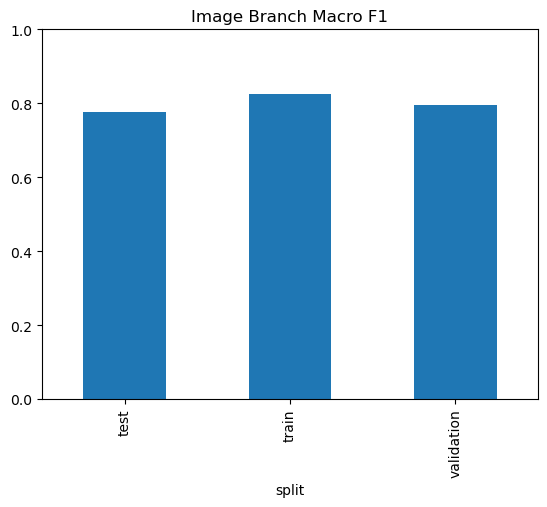

In [3]:
rows = []
for split, payload in output_metrics['splits'].items():
    m = payload['metrics']
    rows.append({'split': split, 'rows': payload['rows'], 'macro_f1': m['macro_f1'], 'accuracy': m['accuracy'], 'roc_auc': m['roc_auc']})
image_eval = pd.DataFrame(rows).sort_values('split')
display(image_eval)
image_eval.plot.bar(x='split', y='macro_f1', legend=False, title='Image Branch Macro F1')
plt.ylim(0, 1)
plt.show()

In [4]:
for split in ['validation', 'test']:
    print(split.upper())
    cm = output_metrics['splits'][split]['metrics']['confusion_matrix']
    display(pd.DataFrame(cm, index=['true_real', 'true_fake'], columns=['pred_real', 'pred_fake']))

VALIDATION


,pred_real,pred_fake
true_real,1666,201
true_fake,574,1357


TEST


,pred_real,pred_fake
true_real,1659,207
true_fake,628,1286


## Viva Note
Say: the image branch is a meaningful visual signal, but it is not the main novelty. The main contribution is the adaptive fusion policy that learns when to trust image versus text signals.

In [5]:
# Reproduction command, expensive:
# %cd /content/drive/MyDrive/fake-news-rl-fusion
# !python scripts/train_image_model.py --config configs/final_image_model_fast.yaml
# !python scripts/infer_image_model.py --config configs/final_image_model.yaml